# Train model and then save to Google Drive

In [4]:
import zipfile

zip_file_path = '/content/AI_Ass3data (1).zip'
extract_to_path = '/content/AI_Ass3data (1)'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Paths to dataset
train_dir = "/content/AI_Ass3data (1)/AI_Ass3data/train"
test_dir = "/content/AI_Ass3data (1)/AI_Ass3data/test"

# Image dimensions and batch size
img_height, img_width = 150, 150
batch_size = 32

# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

# Load MobileNetV2 pretrained model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model
base_model.trainable = False

# Build the model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to avoid overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.2f}")

# Save the model
model.save('/content/drive/MyDrive/cat_dog_classifier.h5')

Found 2000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


9406464/9406464 [==============================] - 0s 0us/step
Epoch 1/10
63/63 [==============================] - 19s 270ms/step - loss: 0.2502 - accuracy: 0.8920 - val_loss: 0.1264 - val_accuracy: 0.9475
Epoch 2/10
63/63 [==============================] - 16s 253ms/step - loss: 0.1652 - accuracy: 0.9335 - val_loss: 0.1101 - val_accuracy: 0.9625
Epoch 3/10
63/63 [==============================] - 16s 251ms/step - loss: 0.1487 - accuracy: 0.9435 - val_loss: 0.0973 - val_accuracy: 0.9663
Epoch 4/10
63/63 [==============================] - 16s 254ms/step - loss: 0.1453 - accuracy: 0.9400 - val_loss: 0.1141 - val_accuracy: 0.9563
Epoch 5/10
63/63 [==============================] - 16s 250ms/step - loss: 0.1485 - accuracy: 0.9400 - val_loss: 0.1416 - val_accuracy: 0.9463
Epoch 6/10
63/63 [==============================] - 16s 251ms/step - loss: 0.1213 - accuracy: 0.9515 - val_loss: 0.1039 - val_accuracy: 0.9613
Epoch 7/10
63/63 [==============================] - 16s 246ms/step - loss: 0.13

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Generate metrics

Found 800 images belonging to 2 classes.
25/25 [==============================] - 3s 95ms/step
True Positives (TP): 385
False Positives (FP): 12
False Negatives (FN): 15
True Negatives (TN): 388
Precision: 0.97
Recall: 0.96
Accuracy: 0.97


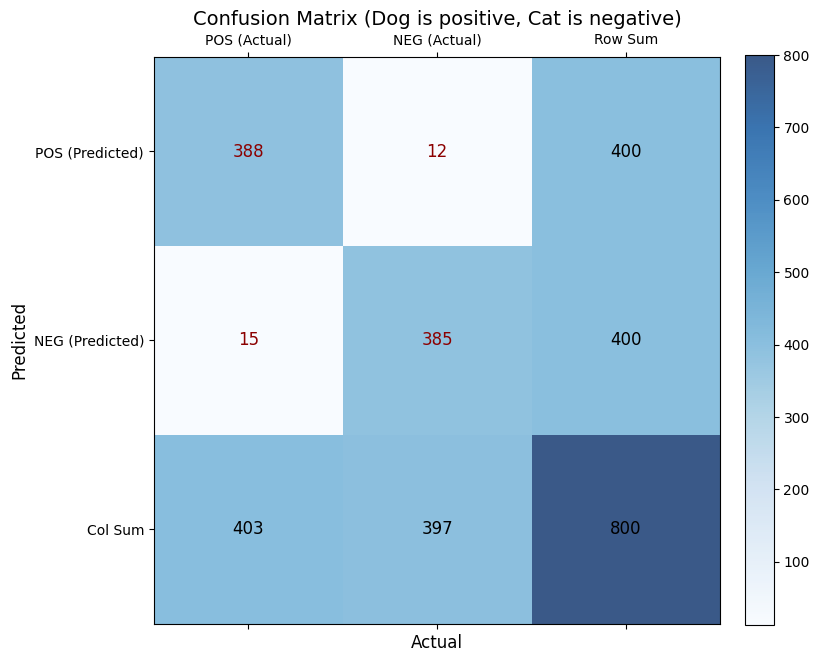

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix

# Load the trained model
model_path = "/content/drive/MyDrive/cat_dog_classifier.h5"
model = load_model(model_path)

# Image dimensions and batch size
img_height, img_width = 150, 150
batch_size = 32

# Test data generator
test_dir = "/content/AI_Ass3data (1)/AI_Ass3data/test"
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False  # Keep labels aligned with predictions
)

# Get true labels and predicted labels
y_true = test_generator.classes  # True labels
y_pred_probs = model.predict(test_generator)  # Predicted probabilities
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Extract confusion matrix components
TP = cm[1, 1]  # True Positives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives
TN = cm[0, 0]  # True Negatives

# Print confusion matrix components
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN): {TN}")

# Calculate metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Print metrics
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"Accuracy: {accuracy:.2f}")

# Visualize the confusion matrix
row_sums = cm.sum(axis=1)
col_sums = cm.sum(axis=0)
total_sum = cm.sum()

# Create an extended confusion matrix
extended_cm = np.zeros((3, 3), dtype=int)
extended_cm[:2, :2] = cm  # Original confusion matrix
extended_cm[:2, 2] = row_sums  # Row sums
extended_cm[2, :2] = col_sums  # Column sums
extended_cm[2, 2] = total_sum  # Total sum

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.matshow(extended_cm, cmap="Blues", alpha=0.8)

# Add labels
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["POS (Actual)", "NEG (Actual)", "Row Sum"], fontsize=10)
ax.set_yticklabels(["POS (Predicted)", "NEG (Predicted)", "Col Sum"], fontsize=10)
ax.set_xlabel("Actual", fontsize=12)
ax.set_ylabel("Predicted", fontsize=12)

# Annotate the matrix
for i in range(3):
    for j in range(3):
        color = "darkred" if (i < 2 and j < 2) else "black"  # Highlight main cells
        ax.text(j, i, f"{extended_cm[i, j]}", ha="center", va="center", color=color, fontsize=12)

# Add title and color bar
plt.title("Confusion Matrix (Dog is positive, Cat is negative)", fontsize=14)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()


# Load model from Google Drive

In [8]:
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image
from IPython.display import Image, display
# Load the saved model
model = load_model('/content/drive/MyDrive/cat_dog_classifier.h5')
img_height, img_width = 150, 150

def predict_image(img_path):
    display(Image(filename=img_path))
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    prediction = model.predict(img_array)
    class_label = 'Dog' if prediction[0][0] > 0.5 else 'Cat'
    confidence = (0.5 - prediction[0][0]) * 2 if prediction[0][0] < 0.5 else (prediction[0][0] - 0.5) * 2
    print(f"Predicted: {class_label} (Confidence: {confidence:.2f})")


# Test out images from the internet

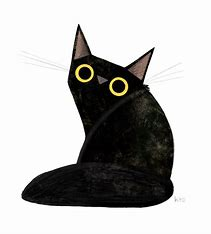

1/1 [==============================] - 1s 737ms/step
Predicted: Cat (Confidence: 1.00)


In [9]:
predict_image("/content/download (1).jpg")

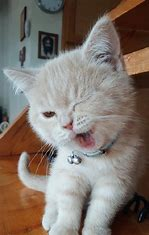

1/1 [==============================] - 0s 42ms/step
Predicted: Cat (Confidence: 1.00)


In [10]:
predict_image("/content/OIP (1).jpg")

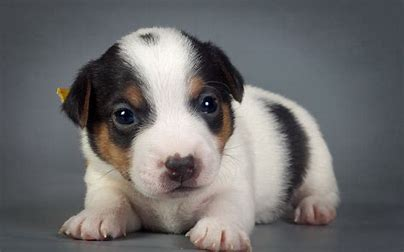

1/1 [==============================] - 0s 42ms/step
Predicted: Dog (Confidence: 1.00)


In [11]:
predict_image("/content/OIP (2).jpg")